In [3]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install mysql-connector-python

In [4]:
import mysql.connector

print("MySQL connector installed successfully!")

MySQL connector installed successfully!


In [5]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="bank_transaction_db"
)

print("Connected to MySQL successfully!")

Connected to MySQL successfully!


In [6]:
query = """
SELECT *
FROM transactions
LIMIT 10;
"""

df_sql = pd.read_sql(query, conn)

df_sql

/var/folders/nq/r0ms5dr12pxcgqxvj6ntw5jm0000gn/T/ipykernel_4665/2929346447.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql(query, conn)


,transaction_id,customer_id,transaction_date,transaction_time,account_type,transaction_type,transaction_amount,transaction_direction,account_balance,merchant_category,state,credit_score,has_loan,loan_type,emi_amount,transaction_status,channel,kyc_status,is_fraud,transaction_hour
0,TXN000000001,CUST015796,2019-01-01,0 days 15:28:00,Current,UPI,1820.17,Debit,609365.31,Food & Dining,Maharashtra,764,0,,0.00,Success,Branch,Verified,0,15
1,TXN000000002,CUST000861,2019-01-01,0 days 03:00:00,Current,UPI,392.67,Credit,14451.14,Education,West Bengal,630,0,,0.00,Success,Mobile_App,Verified,0,3
2,TXN000000003,CUST076821,2019-01-01,0 days 18:03:00,Fixed Deposit,POS,1255.97,Debit,47621.87,Utilities,Punjab,813,1,Home,1433.91,Success,Mobile_App,Verified,0,18
3,TXN000000004,CUST054887,2019-01-01,0 days 08:03:00,Savings,UPI,2580.68,Debit,34467.85,Travel,Karnataka,628,1,Personal,6280.35,Success,API,Verified,0,8
4,TXN000000005,CUST006266,2019-01-01,0 days 14:23:00,Fixed Deposit,UPI,2573.80,Debit,26617.40,Utilities,West Bengal,767,0,,0.00,Success,API,Verified,0,14
5,TXN000000006,CUST037195,2019-01-01,0 days 01:51:00,Fixed Deposit,Net_Banking,39172.48,Debit,1798.86,Government,Karnataka,707,1,Auto,4197.37,Pending,Web,Verified,0,1
6,TXN000000007,CUST044132,2019-01-01,0 days 06:27:00,Savings,NEFT,4008.09,Credit,177668.37,Investment,Punjab,361,1,Home,4251.79,Success,ATM,Verified,0,6
7,TXN000000008,CUST060264,2019-01-01,0 days 23:40:00,Current,Net_Banking,17797.85,Debit,17568.23,Healthcare,Punjab,651,0,,0.00,Success,Mobile_App,Expired,0,23
8,TXN000000009,CUST016024,2019-01-01,0 days 20:25:00,Salary,Credit_Card,3284.62,Debit,66973.00,Food & Dining,Tamil Nadu,443,0,,0.00,Success,Web,Verified,0,20
9,TXN000000010,CUST041091,2019-01-01,0 days 22:15:00,Savings,Net_Banking,921.64,Debit,36054.94,Real Estate,Karnataka,330,1,Personal,9630.13,Success,Web,Verified,0,22


In [7]:
query = """
SELECT
    transaction_type,
    COUNT(*) AS total_transactions,
    SUM(transaction_amount) AS total_amount
FROM transactions
GROUP BY transaction_type
ORDER BY total_amount DESC;
"""

df_type = pd.read_sql(query, conn)

df_type

/var/folders/nq/r0ms5dr12pxcgqxvj6ntw5jm0000gn/T/ipykernel_4665/2246603597.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_type = pd.read_sql(query, conn)


,transaction_type,total_transactions,total_amount
0,RTGS,32964,8.875703e+09
1,Cheque,21711,2.830290e+09
2,NEFT,66615,2.762128e+09
3,Net_Banking,38458,8.198261e+08
4,IMPS,77038,5.407691e+08
5,UPI,153986,2.092383e+08
6,ATM_Withdrawal,55106,1.335500e+08
7,POS,60278,1.203425e+08
8,Credit_Card,16426,8.290444e+07
9,Auto_Debit,27418,7.415138e+07


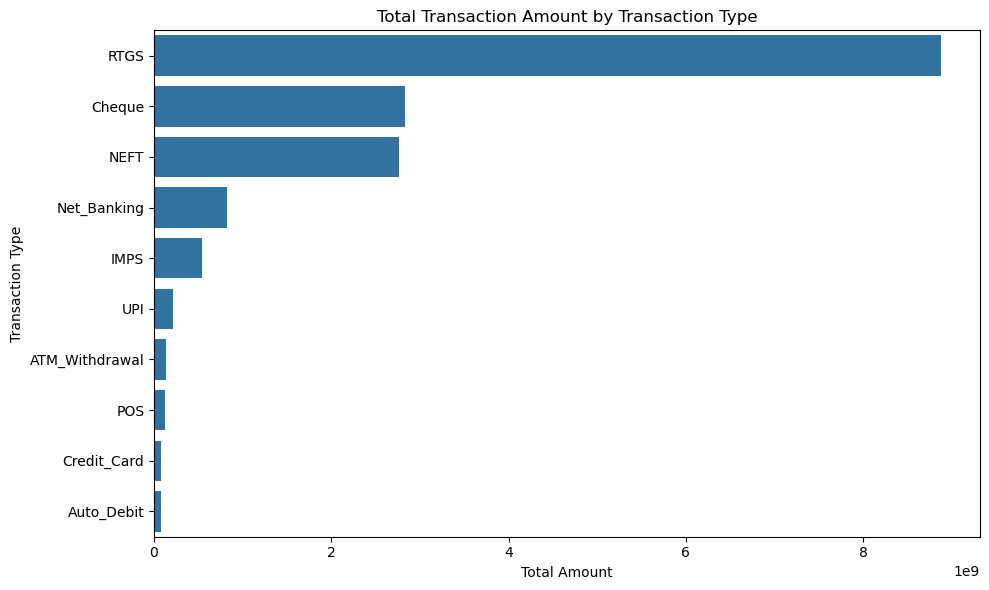

In [8]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_type,
    x="total_amount",
    y="transaction_type"
)

plt.title("Total Transaction Amount by Transaction Type")
plt.xlabel("Total Amount")
plt.ylabel("Transaction Type")
plt.tight_layout()
plt.show()

In [9]:
query = """
SELECT
    transaction_type,
    COUNT(*) AS total_transactions,
    SUM(is_fraud) AS fraud_transactions,
    ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 2) AS fraud_rate_percent
FROM transactions
GROUP BY transaction_type
ORDER BY fraud_rate_percent DESC;
"""

df_fraud = pd.read_sql(query, conn)

df_fraud

/var/folders/nq/r0ms5dr12pxcgqxvj6ntw5jm0000gn/T/ipykernel_4665/1112766638.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_fraud = pd.read_sql(query, conn)


,transaction_type,total_transactions,fraud_transactions,fraud_rate_percent
0,RTGS,32964,611.0,1.85
1,Cheque,21711,256.0,1.18
2,NEFT,66615,581.0,0.87
3,Net_Banking,38458,326.0,0.85
4,Credit_Card,16426,140.0,0.85
5,ATM_Withdrawal,55106,456.0,0.83
6,IMPS,77038,624.0,0.81
7,POS,60278,481.0,0.80
8,UPI,153986,1211.0,0.79
9,Auto_Debit,27418,187.0,0.68


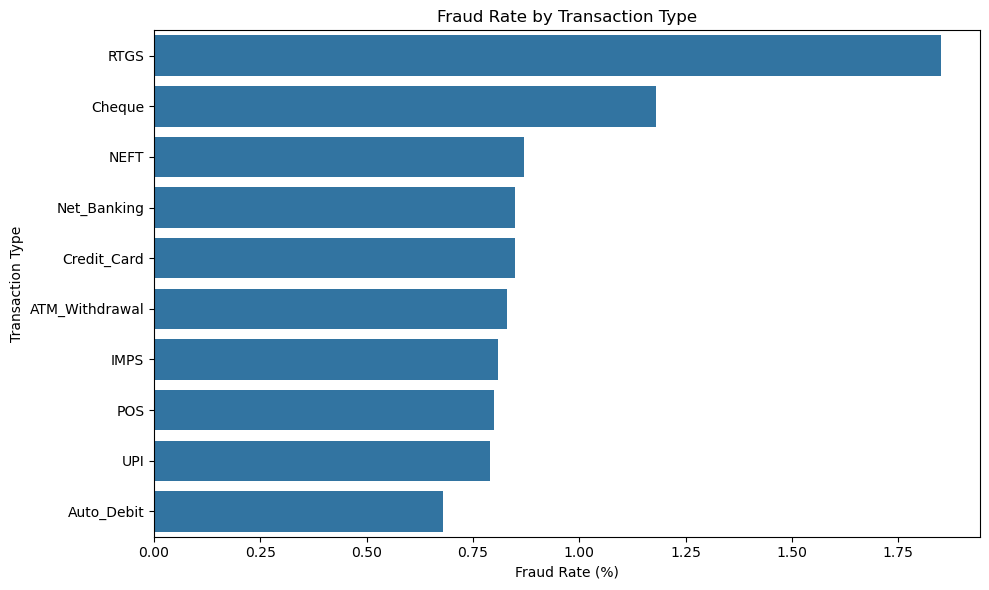

In [10]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_fraud,
    x="fraud_rate_percent",
    y="transaction_type"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Transaction Type")
plt.tight_layout()
plt.show()

In [11]:
query = """
SELECT
    risk_category,
    COUNT(*) AS total_transactions,
    SUM(is_fraud) AS fraud_transactions,
    ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 2) AS fraud_rate_percent
FROM
(
    SELECT
        is_fraud,
        CASE
            WHEN transaction_amount > 1000000
                 AND transaction_type IN ('NEFT', 'RTGS', 'Cheque')
                THEN 'High Risk'
            WHEN transaction_amount > 1000000
                 OR transaction_type IN ('NEFT', 'RTGS', 'Cheque')
                THEN 'Medium Risk'
            ELSE 'Low Risk'
        END AS risk_category
    FROM transactions
) AS risk_data
GROUP BY risk_category
ORDER BY
    CASE risk_category
        WHEN 'High Risk' THEN 1
        WHEN 'Medium Risk' THEN 2
        WHEN 'Low Risk' THEN 3
    END;
"""

df_risk = pd.read_sql(query, conn)

df_risk

/var/folders/nq/r0ms5dr12pxcgqxvj6ntw5jm0000gn/T/ipykernel_4665/3430849723.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_risk = pd.read_sql(query, conn)


,risk_category,total_transactions,fraud_transactions,fraud_rate_percent
0,High Risk,1733,144.0,8.31
1,Medium Risk,119570,1304.0,1.09
2,Low Risk,428697,3425.0,0.80


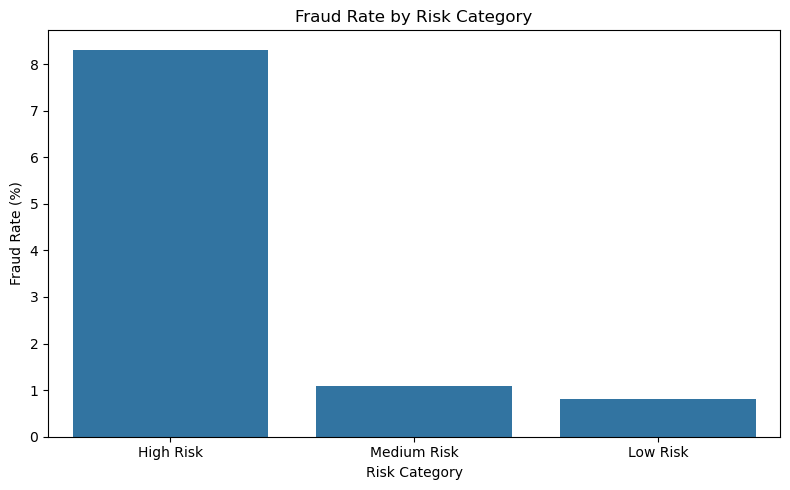

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_risk,
    x="risk_category",
    y="fraud_rate_percent"
)

plt.title("Fraud Rate by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

In [13]:
query = """
SELECT
    customer_id,
    COUNT(*) AS total_transactions,
    SUM(transaction_amount) AS total_expense
FROM transactions
WHERE transaction_direction = 'Debit'
GROUP BY customer_id
ORDER BY total_expense DESC
LIMIT 10;
"""

df_top_customers = pd.read_sql(query, conn)

df_top_customers

/var/folders/nq/r0ms5dr12pxcgqxvj6ntw5jm0000gn/T/ipykernel_4665/512562791.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top_customers = pd.read_sql(query, conn)


,customer_id,total_transactions,total_expense
0,CUST038846,12,10169933.88
1,CUST053927,5,10009941.89
2,CUST061467,5,10002756.74
3,CUST044606,6,8251957.17
4,CUST032072,6,8023774.73
5,CUST044006,6,7975821.33
6,CUST005649,10,7797284.11
7,CUST042673,5,7644323.03
8,CUST012819,5,7216746.93
9,CUST055644,4,7187238.68


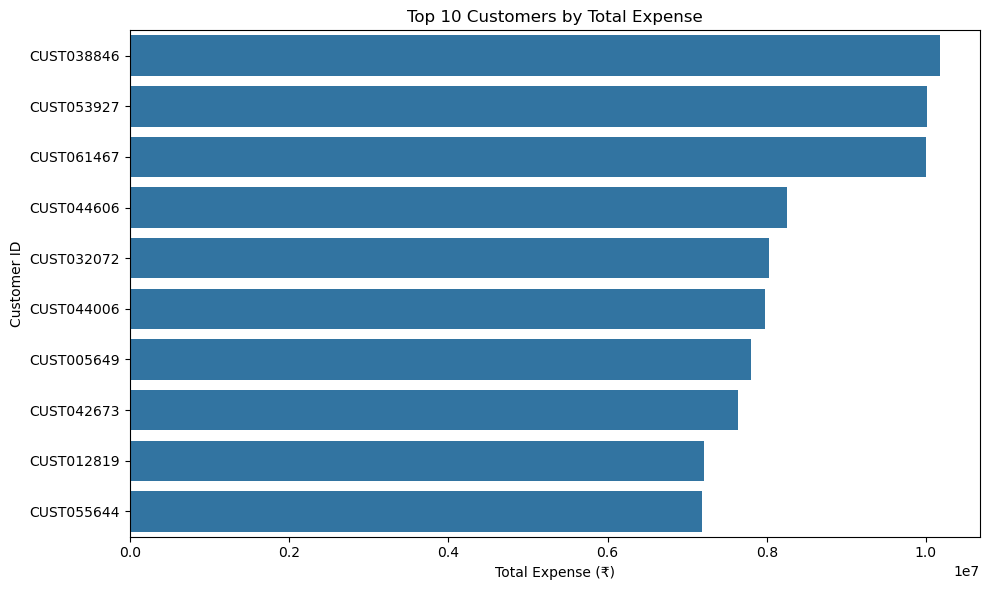

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_top_customers,
    x="total_expense",
    y="customer_id"
)

plt.title("Top 10 Customers by Total Expense")
plt.xlabel("Total Expense (₹)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

In [15]:
query = """
SELECT
    YEAR(transaction_date) AS year,
    MONTH(transaction_date) AS month,
    SUM(transaction_amount) AS total_expense
FROM transactions
WHERE transaction_direction = 'Debit'
GROUP BY YEAR(transaction_date), MONTH(transaction_date)
ORDER BY year, month;
"""

df_monthly = pd.read_sql(query, conn)

df_monthly.head()

/var/folders/nq/r0ms5dr12pxcgqxvj6ntw5jm0000gn/T/ipykernel_4665/86578809.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_monthly = pd.read_sql(query, conn)


,year,month,total_expense
0,2019,1,1.313650e+08
1,2019,2,1.272525e+08
2,2019,3,1.398606e+08
3,2019,4,1.493258e+08
4,2019,5,1.395787e+08


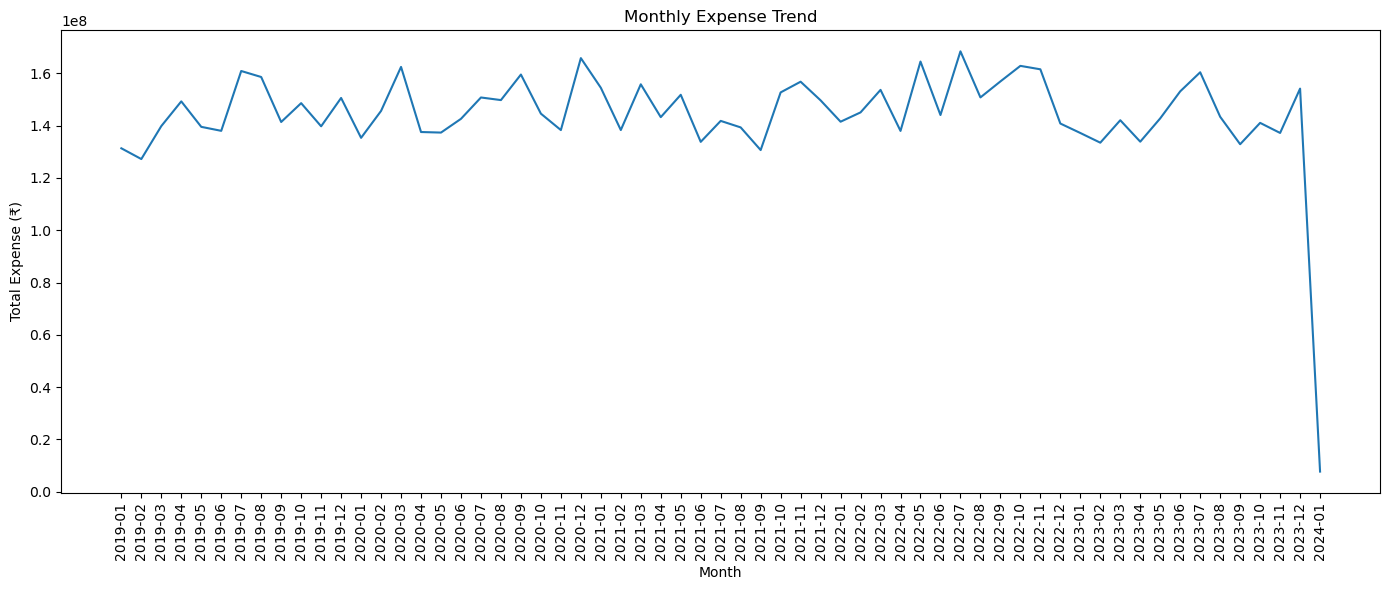

In [16]:
df_monthly["period"] = (
    df_monthly["year"].astype(str)
    + "-"
    + df_monthly["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(14, 6))

plt.plot(
    df_monthly["period"],
    df_monthly["total_expense"]
)

plt.title("Monthly Expense Trend")
plt.xlabel("Month")
plt.ylabel("Total Expense (₹)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [17]:
query = """
SELECT
    channel,
    SUM(CASE WHEN is_fraud = 0 THEN 1 ELSE 0 END) AS normal_transactions,
    SUM(CASE WHEN is_fraud = 1 THEN 1 ELSE 0 END) AS fraud_transactions
FROM transactions
GROUP BY channel
ORDER BY fraud_transactions DESC;
"""

df_channel_fraud = pd.read_sql(query, conn)

df_channel_fraud

/var/folders/nq/r0ms5dr12pxcgqxvj6ntw5jm0000gn/T/ipykernel_4665/76919730.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_channel_fraud = pd.read_sql(query, conn)


,channel,normal_transactions,fraud_transactions
0,Mobile_App,206559.0,1809.0
1,Web,119930.0,1080.0
2,ATM,65616.0,561.0
3,POS_Terminal,60296.0,557.0
4,Branch,54437.0,520.0
5,API,38289.0,346.0


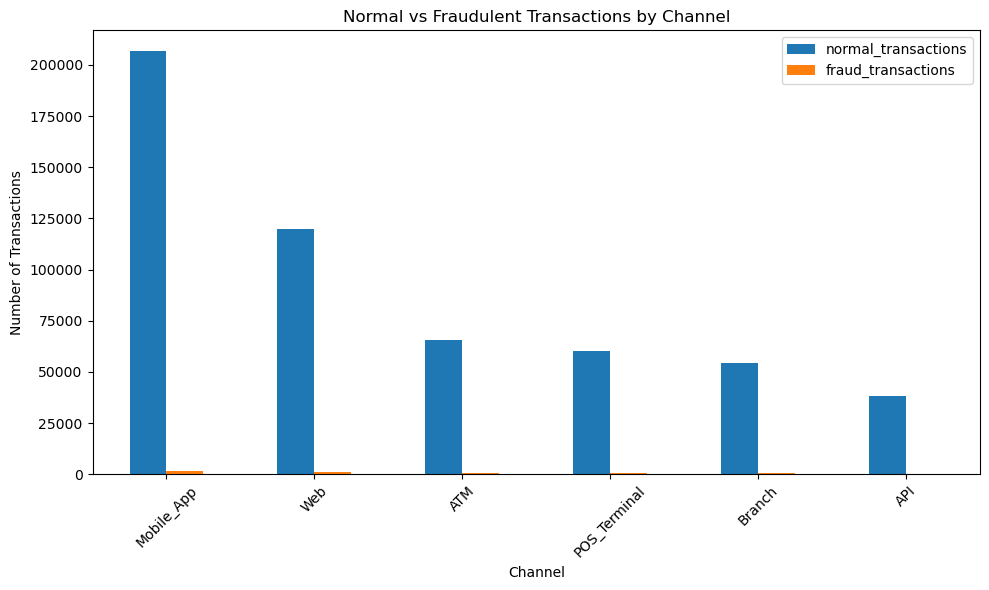

In [18]:
df_channel_fraud.set_index("channel").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Normal vs Fraudulent Transactions by Channel")
plt.xlabel("Channel")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
excel_file = "../output/bank_transaction_analysis.xlsx"

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    df_type.to_excel(writer, sheet_name="Transaction Types", index=False)
    df_fraud.to_excel(writer, sheet_name="Fraud Analysis", index=False)
    df_risk.to_excel(writer, sheet_name="Risk Analysis", index=False)
    df_top_customers.to_excel(writer, sheet_name="Top Customers", index=False)
    df_monthly.to_excel(writer, sheet_name="Monthly Expenses", index=False)
    df_channel_fraud.to_excel(writer, sheet_name="Channel Fraud", index=False)

print("Excel file created successfully!")

Excel file created successfully!


In [20]:
import os

print(os.path.exists(excel_file))

True


In [21]:
summary_data = {
    "Metric": [
        "Total Transactions",
        "Total Income",
        "Total Expense",
        "Average Transaction Amount",
        "Total Fraud Transactions",
        "Overall Fraud Rate (%)"
    ],
    "Value": [
        550000,
        7655754979.94,
        8793146683.62,
        29907.09,
        4873,
        round(4873 * 100 / 550000, 2)
    ]
}

df_summary = pd.DataFrame(summary_data)

df_summary

,Metric,Value
0,Total Transactions,5.500000e+05
1,Total Income,7.655755e+09
2,Total Expense,8.793147e+09
3,Average Transaction Amount,2.990709e+04
4,Total Fraud Transactions,4.873000e+03
5,Overall Fraud Rate (%),8.900000e-01


In [22]:
with pd.ExcelWriter(
    excel_file,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    df_summary.to_excel(
        writer,
        sheet_name="Overall Summary",
        index=False
    )

print("Overall Summary added successfully!")

Overall Summary added successfully!
